In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [3]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [4]:
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_loader = DataLoader(trainset, batch_size=128, shuffle=True)
test_loader = DataLoader(testset, batch_size=128, shuffle=False)

In [6]:
input_dim = 3072

In [7]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=512):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [8]:
def sparsity_penalty(encoded, sparsity_target=0.05, sparsity_lambda=1e-3):

    rho_hat = torch.mean(encoded, dim=0)
    rho = torch.tensor([sparsity_target]*len(rho_hat)).to(encoded.device)

    kl_div = rho * torch.log(rho / rho_hat) + (1-rho) * torch.log((1-rho)/(1-rho_hat))

    return sparsity_lambda * torch.sum(kl_div)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

In [10]:
train_losses = []

for epoch in range(epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)  # flatten

        optimizer.zero_grad()

        encoded, outputs = model(images)

        mse_loss = criterion(outputs, images)
        sparse_loss = sparsity_penalty(encoded)

        loss = mse_loss + sparse_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/20] Loss: 0.2519
Epoch [2/20] Loss: 0.2103
Epoch [3/20] Loss: 0.1970
Epoch [4/20] Loss: 0.1869
Epoch [5/20] Loss: 0.1807
Epoch [6/20] Loss: 0.1770
Epoch [7/20] Loss: 0.1749
Epoch [8/20] Loss: 0.1736
Epoch [9/20] Loss: 0.1729
Epoch [10/20] Loss: 0.1721
Epoch [11/20] Loss: 0.1721
Epoch [12/20] Loss: 0.1715
Epoch [13/20] Loss: 0.1711
Epoch [14/20] Loss: inf
Epoch [15/20] Loss: inf
Epoch [16/20] Loss: 0.1709
Epoch [17/20] Loss: 0.1704
Epoch [18/20] Loss: 0.1706
Epoch [19/20] Loss: 0.1702
Epoch [20/20] Loss: inf


In [11]:
model.eval()
test_loss = 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.view(images.size(0), -1).to(device)
        _, outputs = model(images)
        loss = criterion(outputs, images)
        test_loss += loss.item()
test_loss /= len(test_loader)
print("Test Reconstruction Loss:", test_loss)

Test Reconstruction Loss: 0.16413749037664147


In [12]:
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)
flat = images.view(images.size(0), -1)
_, reconstructed = model(flat)
images = images.cpu().numpy()
reconstructed = reconstructed.view(-1,3,32,32).cpu().detach().numpy()

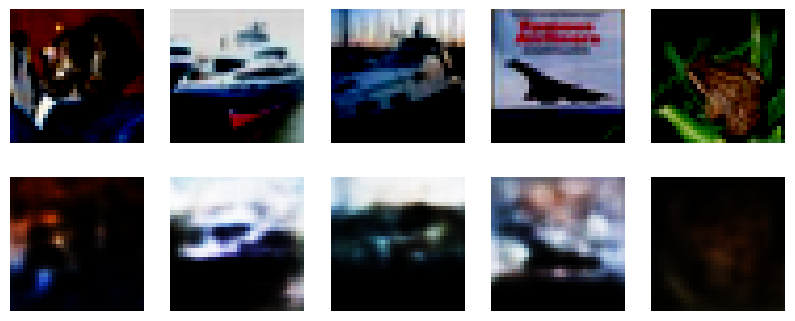

In [13]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(np.transpose(images[i], (1,2,0)))
    plt.axis("off")
    plt.subplot(2,5,i+6)
    plt.imshow(np.transpose(reconstructed[i], (1,2,0)))
    plt.axis("off")
plt.show()

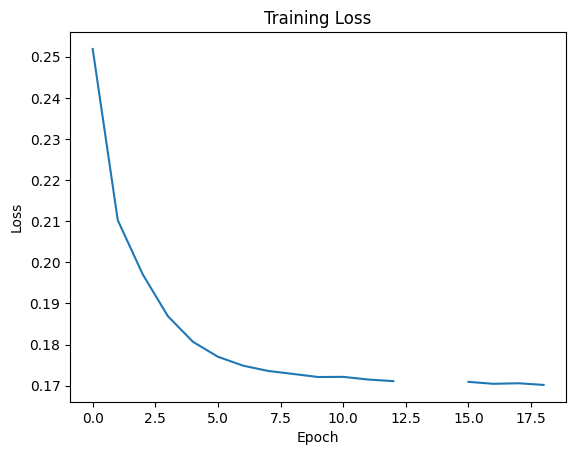

In [14]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()